# Week 3 Assignment — Customer Intelligence System

**Name:** Bhavya Jain

**Objective:** Develop a Customer Intelligence System using classification, ensemble learning and clustering on country-level socio-economic data.


## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import os
os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, accuracy_score, f1_score, classification_report
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 2. Load the dataset

In [2]:
df = pd.read_csv("Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 3. Basic data check

In [3]:
print('Shape:', df.shape)
display(df.head())
df.info()
print("\nColumn types:")
print(df.dtypes)
numeric_cols = df.select_dtypes(include=np.number).columns
display(df[numeric_cols].describe().T)

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB

Column types:
country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


## 4. Data cleaning

The cleaning chain follows these steps:
- strip whitespace from column titles
- remove duplicate records
- clean the country name column
- force feature columns into numeric format
- fill missing numeric values with median values


In [4]:
df.columns = df.columns.str.strip()

df = df.drop_duplicates().reset_index(drop=True)

if "country" in df.columns:
    df["country"] = df["country"].astype(str).str.strip()

for col in df.columns:
    if col != "country":
        df[col] = pd.to_numeric(df[col], errors="coerce")

numeric_cols = df.drop(columns=["country"]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("Shape after cleaning:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Missing values after cleaning:")
print(df.isnull().sum())

Shape after cleaning: (167, 10)
Duplicate rows: 0
Missing values after cleaning:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


## 5. Isolate continuous features and scale them

The country name is kept separately only for interpretation. The clustering models use the continuous numeric features.


In [5]:
countries = df["country"].copy()
features = df.drop(columns=["country"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

scaled_df = pd.DataFrame(X_scaled, columns=features.columns)
scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


## 6. Elbow Method for K-Means

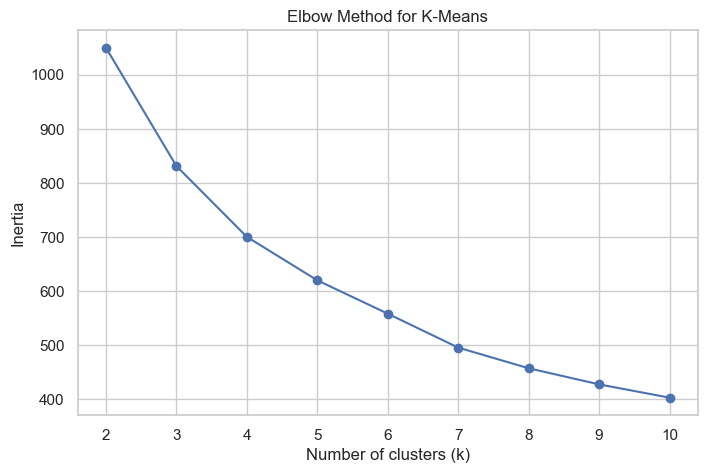

,k,inertia
0,2,1050.214558
1,3,831.424435
2,4,700.520537
3,5,620.163371
4,6,558.469660
5,7,495.807946
6,8,457.586148
7,9,427.803672
8,10,403.229613


In [6]:
k_values = range(2, 11)
inertia_values = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    model.fit(X_scaled)
    inertia_values.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertia_values, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

pd.DataFrame({"k": list(k_values), "inertia": inertia_values})

## 7. Train K-Means model

In [7]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, df["kmeans_cluster"])
print("Silhouette Score:", round(score, 4))

df[["country", "kmeans_cluster"]].head(10)

Silhouette Score: 0.2833


,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2
5,Argentina,2
6,Armenia,2
7,Australia,0
8,Austria,0
9,Azerbaijan,2


## 8. Cluster profile

In [8]:
cluster_profile = df.groupby("kmeans_cluster")[features.columns].mean().round(2)

display(cluster_profile)

print("Countries in each K-Means cluster:")
print(df["kmeans_cluster"].value_counts().sort_index())

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


Countries in each K-Means cluster:
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64


## 9. DBSCAN comparison

In [9]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

print("DBSCAN cluster counts:")
print(df["dbscan_cluster"].value_counts().sort_index())

df[["country", "kmeans_cluster", "dbscan_cluster"]].head(10)

DBSCAN cluster counts:
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


,country,kmeans_cluster,dbscan_cluster
0,Afghanistan,1,0
1,Albania,2,0
2,Algeria,2,0
3,Angola,1,-1
4,Antigua and Barbuda,2,0
5,Argentina,2,0
6,Armenia,2,0
7,Australia,0,0
8,Austria,0,0
9,Azerbaijan,2,0


## 10. PCA visualization of K-Means clusters

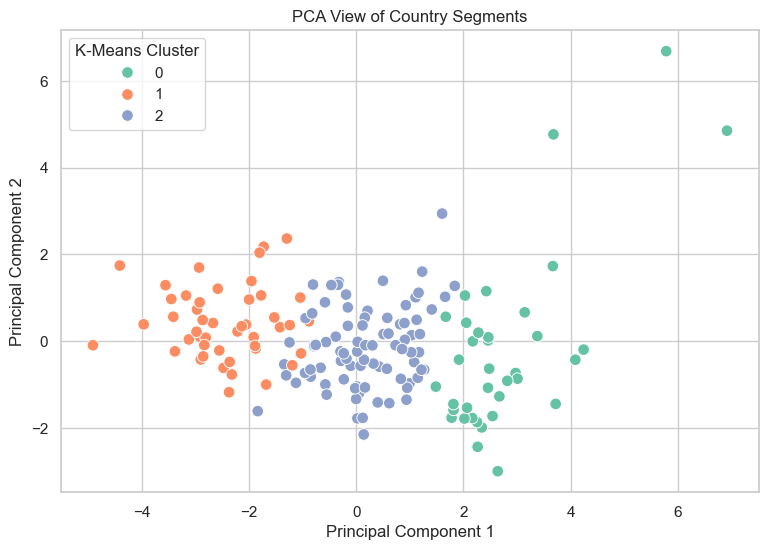

Explained variance ratio: [0.46  0.172]


In [10]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_points = pca.fit_transform(X_scaled)

df["pca_1"] = pca_points[:, 0]
df["pca_2"] = pca_points[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="pca_1",
    y="pca_2",
    hue="kmeans_cluster",
    palette="Set2",
    s=70
)
plt.title("PCA View of Country Segments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="K-Means Cluster")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))

## 11. Create simple segment names

The names below are based on the cluster profile table, not manually assigned country by country.


In [11]:
cluster_summary = df.groupby("kmeans_cluster")[["child_mort", "income", "gdpp", "life_expec"]].mean()

high_mortality_cluster = cluster_summary["child_mort"].idxmax()
top_economy_cluster = cluster_summary["gdpp"].idxmax()

segment_map = {}
for cluster_id in cluster_summary.index:
    if cluster_id == high_mortality_cluster:
        segment_map[cluster_id] = "Low development / high mortality"
    elif cluster_id == top_economy_cluster:
        segment_map[cluster_id] = "High income / developed"
    else:
        segment_map[cluster_id] = "Middle development"

df["segment_name"] = df["kmeans_cluster"].map(segment_map)

display(df[["country", "kmeans_cluster", "segment_name"]].head(15))
print(segment_map)

,country,kmeans_cluster,segment_name
0,Afghanistan,1,Low development / high mortality
1,Albania,2,Middle development
2,Algeria,2,Middle development
3,Angola,1,Low development / high mortality
4,Antigua and Barbuda,2,Middle development
5,Argentina,2,Middle development
6,Armenia,2,Middle development
7,Australia,0,High income / developed
8,Austria,0,High income / developed
9,Azerbaijan,2,Middle development


{0: 'High income / developed', 1: 'Low development / high mortality', 2: 'Middle development'}


## 12. Classification setup

K-Means cluster labels are used as the target. The aim is to check whether supervised models can learn the customer/country segment pattern from the numeric features.


In [12]:
X = X_scaled
y = df["kmeans_cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 125
Testing rows: 42


## 13. Classification and ensemble models

In [13]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=120, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        n_estimators=80,
        max_depth=3,
        learning_rate=0.1,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=0
    )
}

model_scores = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    macro_f1 = f1_score(y_test, preds, average="macro")
    model_scores.append({"model": name, "accuracy": round(acc, 4), "macro_f1": macro_f1})

    print("\n", name)
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_test, preds))

score_df = pd.DataFrame(model_scores)
display(score_df)


 Decision Tree
Accuracy: 0.9762
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      0.92      0.96        12
           2       0.95      1.00      0.98        21

    accuracy                           0.98        42
   macro avg       0.98      0.97      0.98        42
weighted avg       0.98      0.98      0.98        42


 Random Forest
Accuracy: 0.9762
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.92      1.00      0.96        12
           2       1.00      0.95      0.98        21

    accuracy                           0.98        42
   macro avg       0.97      0.98      0.98        42
weighted avg       0.98      0.98      0.98        42


 XGBoost
Accuracy: 0.9762
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      0.92   

,model,accuracy,macro_f1
0,Decision Tree,0.9762,0.977755
1,Random Forest,0.9762,0.978537
2,XGBoost,0.9762,0.977755


## 13.1 Random Forest feature importance

,feature,importance
0,child_mort,0.297060
8,gdpp,0.182607
4,income,0.170156
7,total_fer,0.141407
6,life_expec,0.138461
2,health,0.028457
5,inflation,0.019253
1,exports,0.012119
3,imports,0.010479


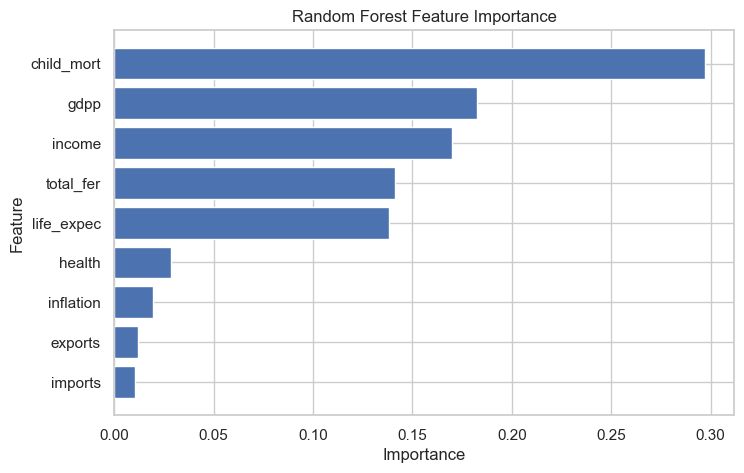

In [14]:
rf_model = models["Random Forest"]

importance_df = pd.DataFrame({
    "feature": features.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### 13.2 Quick check from this run

In [15]:
print("High-mortality cluster:", high_mortality_cluster)
print("Top-tier economic cluster:", top_economy_cluster)

for cluster_id in sorted(df["kmeans_cluster"].unique()):
    sample = df.loc[df["kmeans_cluster"] == cluster_id, "country"].head(8).tolist()
    print(f"Cluster {cluster_id} sample countries:", sample)

High-mortality cluster: 1
Top-tier economic cluster: 0
Cluster 0 sample countries: ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic']
Cluster 1 sample countries: ['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic']
Cluster 2 sample countries: ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh']


## 14. Final Observations

1. **High-mortality cluster:**  
   Cluster 1 is the weakest development group. It has the highest average child mortality, lower life expectancy, low income, and low GDP per capita. Countries in this segment need stronger focus on healthcare, nutrition, child survival, and basic infrastructure.

2. **High-income and high-GDPP group:**  
   Cluster 0 represents the most developed economic segment. It has high income, high GDP per capita, low child mortality, and better life expectancy. These countries appear more stable in terms of socio-economic indicators.

3. **Middle-development group:**  
   Cluster 2 sits between the other two groups. Its mortality rate and income levels are better than Cluster 1, but still below Cluster 0. This group may benefit from targeted economic and healthcare policies.

4. **Aid prioritization:**  
   Countries in Cluster 1 should be prioritized for aid because they show the weakest health and economic indicators. From the clustered results, countries such as Afghanistan, Angola, Benin, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Haiti, Mozambique, Niger, and Sierra Leone are examples of countries that may need stronger development support.

5. **DBSCAN and PCA interpretation:**  
   DBSCAN grouped most countries into one large cluster and marked some countries as outliers, while K-Means gave a clearer three-segment structure. The two-dimensional PCA plot also gives a readable visual separation of the country groups, especially between developed countries and high-mortality/low-development countries.

